In [34]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import os 
import requests 
import opendatasets as od 
from pathlib import Path

In [35]:
dataset_url = "https://www.kaggle.com/datasets/residentmario/ramen-ratings/data"

In [36]:
data_dir = od.download(dataset_url)

Skipping, found downloaded files in ".\ramen-ratings" (use force=True to force download)


In [37]:
data_dir = Path("ramen-ratings")
csv_path = data_dir / "ramen-ratings.csv"

### THE BIG QUESTION:
- DOES JAPAN HAVE THE BEST RAMEN?

In [38]:
df = pd.read_csv(csv_path)
df.head(5)

,Review #,Brand,Variety,Style,Country,Stars,Top Ten
0,2580,New Touch,T's Restaurant Tantanmen,Cup,Japan,3.75,NaN
1,2579,Just Way,Noodles Spicy Hot Sesame Spicy Hot Sesame Guan...,Pack,Taiwan,1,NaN
2,2578,Nissin,Cup Noodles Chicken Vegetable,Cup,USA,2.25,NaN
3,2577,Wei Lih,GGE Ramen Snack Tomato Flavor,Pack,Taiwan,2.75,NaN
4,2576,Ching's Secret,Singapore Curry,Pack,India,3.75,NaN


In [39]:
print(f"Shape: {df.shape}")
print('-'*1000)
df.info()

Shape: (2580, 7)
-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

## Data Cleaning

In [40]:
feature_col = [c for c in df.columns if c not in ('Review #', 'Stars')]

for col in feature_col:
    print(f"{col} ({df[col].nunique()} unique values):")
    print(df[col].unique())
    print('-' * 50)

Brand (355 unique values):
['New Touch' 'Just Way' 'Nissin' 'Wei Lih' "Ching's Secret"
 'Samyang Foods' 'Acecook' 'Ikeda Shoku' "Ripe'n'Dry" 'KOKA' 'Tao Kae Noi'
 'Yamachan' 'Nongshim' 'TRDP' 'Binh Tay' 'Paldo' 'Jackpot Teriyaki'
 'Yum-Mie' 'MyKuali' 'Ottogi' 'Sichuan Guangyou' 'Lipton' 'Lele'
 'Fujiwara' 'Uni-President' 'Maruchan' 'Prima' 'Sokensha' 'Takamori'
 'Guava Story' 'Samurai Ramen' 'Ogasawara' 'Pringles' "Mom's Dry Noodle"
 'Maggi' 'Indomie' 'Happy Cook' 'The Ramen Rater Select' 'TTL' 'E-Zee'
 'Kiki Noodle' 'Tokyo Noodle' 'GGE' 'Myojo' 'Sau Tao' 'Wang' 'Daifuku'
 'Master Kong' "World O' Noodle" 'Kang Shi Fu' 'Mum Ngon' 'Fashion Food'
 'Dream Kitchen' 'Ajinatori' "Dr. McDougall's" 'Ve Wong' 'Super Bihun'
 'Xiuhe' 'Little Cook' 'Shirakiku' "Mama Pat's" 'Goku-Uma'
 'Sichuan Baijia' 'Liang Cheng Mai' 'Gefen' 'Hua Feng' 'Pulmuone'
 'Liu Quan' 'Daikoku' 'Chuan Wei Wang' 'Wai Wai' 'Kamfen' 'Marutai'
 'Vifon' '1 To 3 Noodles' 'Fantastic' 'Knorr' 'Sempio' 'Patanjali'
 'Qin Zong' 'Pran

In [58]:
df_clean = df.copy()
df_clean[["Top Ten Year", "Top Ten Rank"]] = df_clean["Top Ten"].str.extract(r"(\d{4})\s*#(\d+)")
df_clean["Top Ten Year"] = df_clean["Top Ten Year"].astype("Int64")
df_clean["Top Ten Rank"] = df_clean["Top Ten Rank"].astype("Int64")
df_clean["Stars"] = pd.to_numeric(df_clean["Stars"], errors="coerce")
df_clean = df_clean.dropna(subset=["Style", "Stars"])

df_clean

,Review #,Brand,Variety,Style,Country,Stars,Top Ten,Top Ten Year,Top Ten Rank
0,2580,New Touch,T's Restaurant Tantanmen,Cup,Japan,3.75,NaN,<NA>,<NA>
1,2579,Just Way,Noodles Spicy Hot Sesame Spicy Hot Sesame Guan...,Pack,Taiwan,1.00,NaN,<NA>,<NA>
2,2578,Nissin,Cup Noodles Chicken Vegetable,Cup,USA,2.25,NaN,<NA>,<NA>
3,2577,Wei Lih,GGE Ramen Snack Tomato Flavor,Pack,Taiwan,2.75,NaN,<NA>,<NA>
4,2576,Ching's Secret,Singapore Curry,Pack,India,3.75,NaN,<NA>,<NA>
...,...,...,...,...,...,...,...,...,...
2575,5,Vifon,"Hu Tiu Nam Vang [""Phnom Penh"" style] Asian Sty...",Bowl,Vietnam,3.50,NaN,<NA>,<NA>
2576,4,Wai Wai,Oriental Style Instant Noodles,Pack,Thailand,1.00,NaN,<NA>,<NA>
2577,3,Wai Wai,Tom Yum Shrimp,Pack,Thailand,2.00,NaN,<NA>,<NA>
2578,2,Wai Wai,Tom Yum Chili Flavor,Pack,Thailand,2.00,NaN,<NA>,<NA>


# Feature Engineering

In [42]:
df_summary = df(
    
)

TypeError: 'DataFrame' object is not callable

# Step 1
Lets first see which countries along with which brands have the most top ten ratings

In [60]:
df_top10 = df_clean[df_clean["Top Ten"].notna()]
df_top10 = df_top10.drop(columns = "Top Ten")
df_top10 = df_top10.dropna()
print(f"Amount of Rows: {df_top10.shape[0]}")
df_top10.head(10)

Amount of Rows: 37


,Review #,Brand,Variety,Style,Country,Stars,Top Ten Year,Top Ten Rank
616,1964,MAMA,Instant Noodles Coconut Milk Flavour,Pack,Myanmar,5.0,2016,10
633,1947,Prima Taste,Singapore Laksa Wholegrain La Mian,Pack,Singapore,5.0,2016,1
655,1925,Prima,Juzz's Mee Creamy Chicken Flavour,Pack,Singapore,5.0,2016,8
673,1907,Prima Taste,Singapore Curry Wholegrain La Mian,Pack,Singapore,5.0,2016,5
752,1828,Tseng Noodles,Scallion With Sichuan Pepper Flavor,Pack,Taiwan,5.0,2016,9
891,1689,Wugudaochang,Tomato Beef Brisket Flavor Purple Potato Noodle,Pack,China,5.0,2016,7
942,1638,A-Sha Dry Noodle,Veggie Noodle Tomato Noodle With Vine Ripened ...,Pack,Taiwan,5.0,2015,10
963,1617,MyKuali,Penang Hokkien Prawn Noodle (New Improved Taste),Pack,Malaysia,5.0,2015,7
995,1585,CarJEN,Nyonya Curry Laksa,Pack,Malaysia,5.0,2015,4
1059,1521,Maruchan,Gotsumori Sauce Yakisoba,Tray,Japan,5.0,2015,9


# Top Styles of Ramen

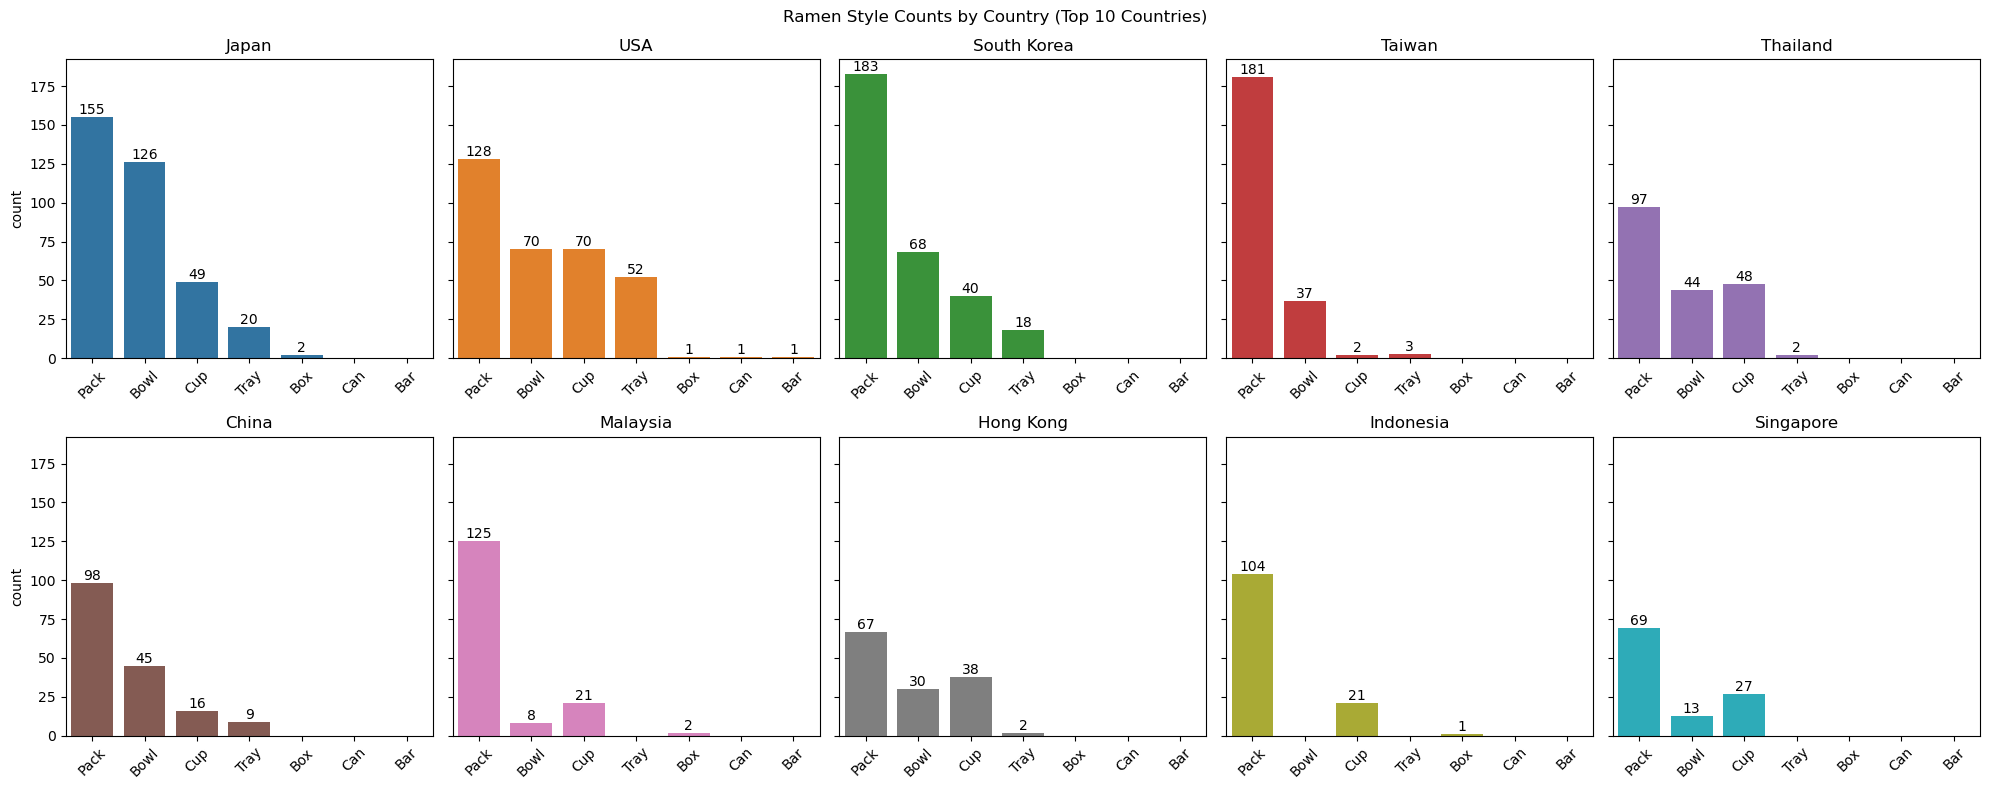

In [61]:
df_style = df.dropna(subset=["Style"]).copy()

top_countries = df_style["Country"].value_counts().nlargest(10).index
style_order = df_style["Style"].value_counts().index
colors = sns.color_palette("tab10", n_colors=len(top_countries))

fig, axes = plt.subplots(2, 5, figsize=(20, 8), sharey=True)
axes = axes.flatten()

for ax, country, color in zip(axes, top_countries, colors):
    country_data = df_style[df_style["Country"] == country]
    sns.countplot(data=country_data, x="Style", order=style_order, ax=ax, color=color)
    ax.set_title(country)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=45)
    ax.bar_label(ax.containers[0])

fig.suptitle("Ramen Style Counts by Country (Top 10 Countries)")
plt.tight_layout()
plt.show()

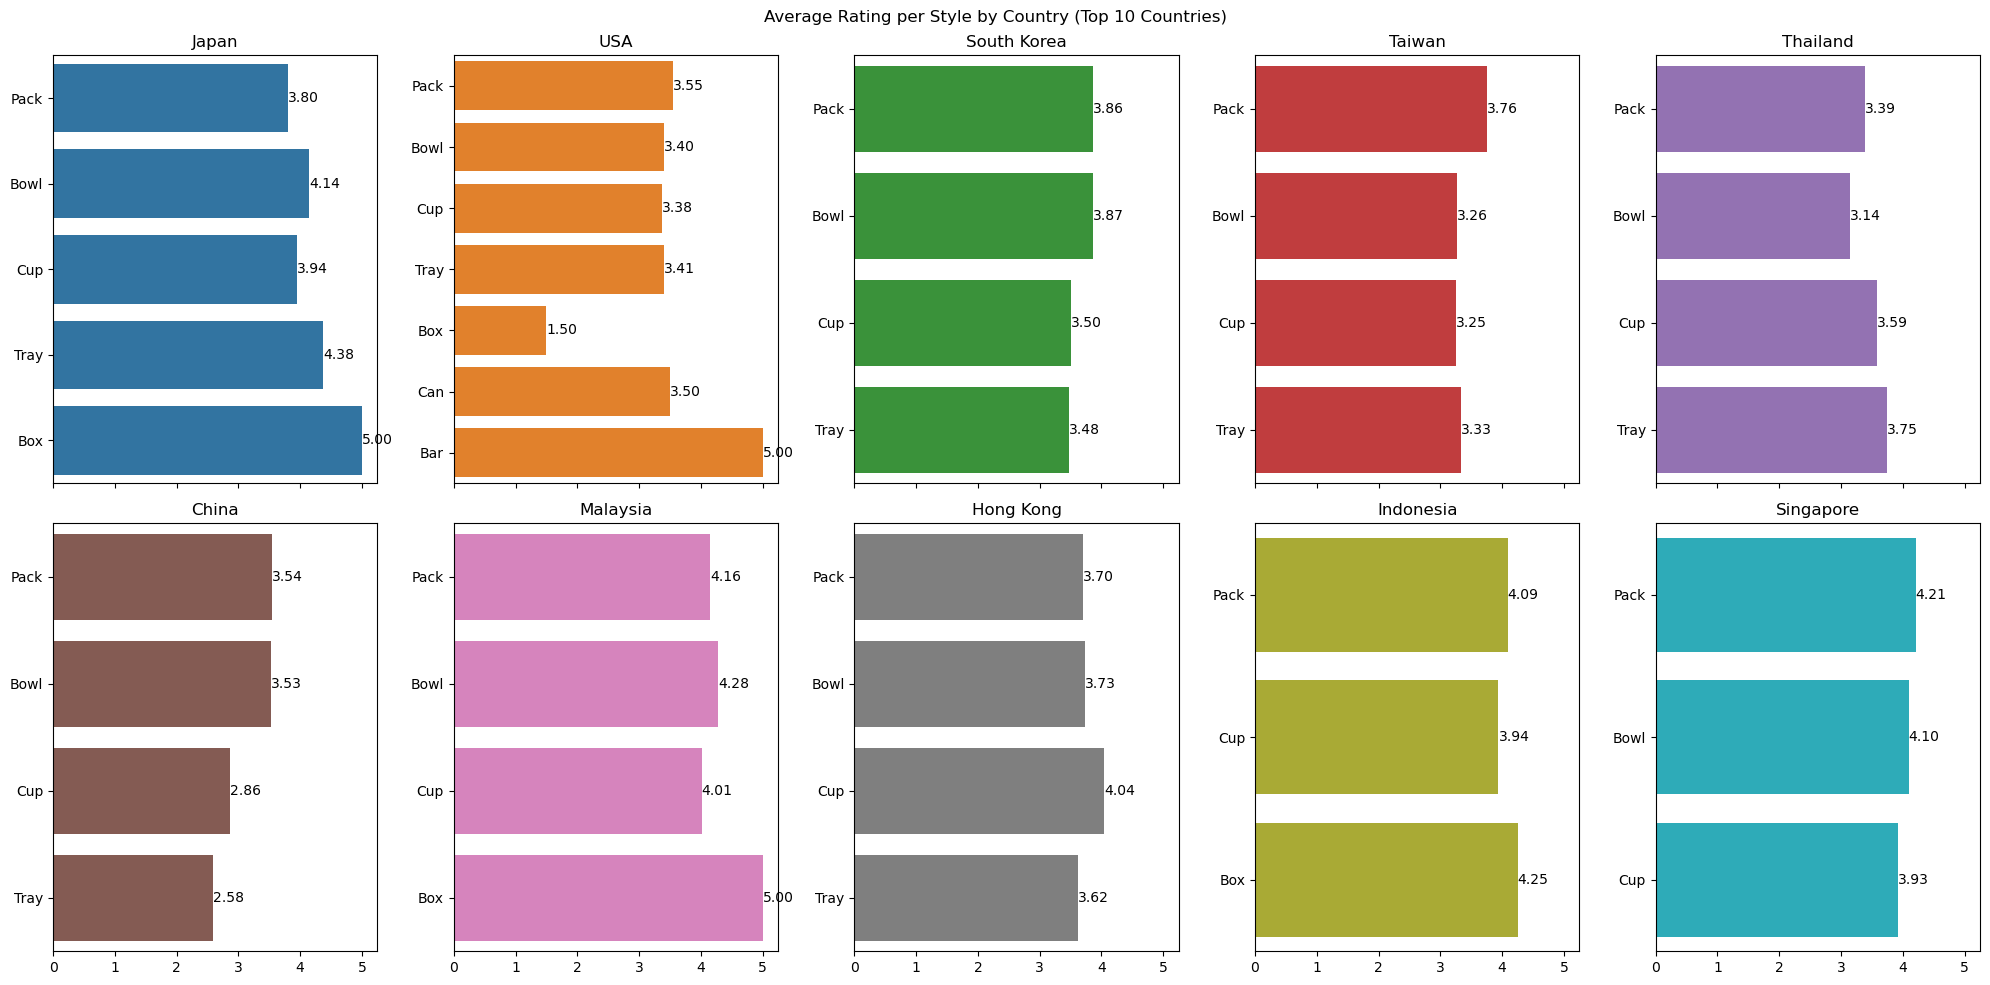

In [63]:
top_countries = df_clean["Country"].value_counts().nlargest(10).index
style_order = df_clean["Style"].value_counts().index
colors = sns.color_palette("tab10", n_colors=len(top_countries))

fig, axes = plt.subplots(2, 5, figsize=(20, 10), sharex=True)
axes = axes.flatten()

for ax, country, color in zip(axes, top_countries, colors):
    country_data = df_clean[df_clean["Country"] == country]
    avg_rating = country_data.groupby("Style")["Stars"].mean().reindex(style_order).dropna()
    sns.barplot(x=avg_rating.values, y=avg_rating.index, ax=ax, color=color)
    ax.set_title(country)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.bar_label(ax.containers[0], fmt="%.2f")

fig.suptitle("Average Rating per Style by Country (Top 10 Countries)")
plt.tight_layout()
plt.show()

There seems to be a preference of style for every Country. For example there are a lot of people in Japan who seem tor prefer Bowl Ramen based off of the rating for Bowl. (Note: we aren't considering box since there are only 2 counts). Meanwhile the trend thhroughout all countries is there is a fondess for Ramen in Packs due to many restaurants/ brands serving their ramen in this format. 